一、导入库

In [5]:
import gym
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
print("GPU可用:", tf.config.list_physical_devices('GPU'))


GPU可用: []


二、创建游戏环境

In [3]:
env = gym.make("CartPole-v1")

# 状态维度：小车位置、速度、杆角度、杆角速度
state_size = env.observation_space.shape[0]

# 动作维度：左、右
action_size = env.action_space.n

三、 DQN智能体类

In [21]:
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.99    # 调高折扣因子，更看重长期奖励
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.99
        self.learning_rate = 0.001
        self.model = self.build_model()
        self.target_model = self.build_model()
        self.update_target_model()

    def build_model(self):
        model = models.Sequential()
        model.add(layers.Dense(64, activation='relu', input_shape=(self.state_size,))) # 增大网络容量
        model.add(layers.Dense(64, activation='relu'))
        model.add(layers.Dense(self.action_size, activation='linear'))
        model.compile(loss='mse', optimizer=optimizers.Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])

    def replay(self, batch_size):
        minibatch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in minibatch:
            target = self.model.predict(state, verbose=0)
            if done:
                target[0][action] = reward
            else:
                t = self.target_model.predict(next_state, verbose=0)[0]
                target[0][action] = reward + self.gamma * np.amax(t)
            self.model.fit(state, target, epochs=1, verbose=0)
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

四、开始训练 DQN

In [ ]:
agent = DQNAgent(state_size, action_size)
batch_size = 64  # 增大batch size，训练更稳定
episodes = 300
scores = []

for e in range(episodes):
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])
    score = 0

    while True:
        action = agent.act(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        # 奖励优化：杆子角度越大，奖励越低，鼓励保持平衡
        x, x_dot, theta, theta_dot = next_state
        r1 = (env.x_threshold - abs(x)) / env.x_threshold - 0.8
        r2 = (env.theta_threshold_radians - abs(theta)) / env.theta_threshold_radians - 0.5
        reward = r1 + r2
        next_state = np.reshape(next_state, [1, state_size])
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        score += 1
        if done:
            break

    # 每回合训练多次，提高样本利用率
    if len(agent.memory) > batch_size:
        for _ in range(5):
            agent.replay(batch_size)

    # 每2回合更新目标网络，更稳定
    if e % 2 == 0:
        agent.update_target_model()

    scores.append(score)
    print(f"回合: {e+1}/{episodes}, 得分: {score}, 探索率: {agent.epsilon:.2f} {'【满分】' if score==500 else ''}")

回合: 1/300, 得分: 13, 探索率: 1.00 
回合: 2/300, 得分: 37, 探索率: 1.00 
回合: 3/300, 得分: 13, 探索率: 1.00 
回合: 4/300, 得分: 11, 探索率: 0.95 
回合: 5/300, 得分: 21, 探索率: 0.90 
回合: 6/300, 得分: 11, 探索率: 0.86 
回合: 7/300, 得分: 17, 探索率: 0.82 
回合: 8/300, 得分: 37, 探索率: 0.78 
回合: 9/300, 得分: 12, 探索率: 0.74 
回合: 10/300, 得分: 57, 探索率: 0.70 
回合: 11/300, 得分: 28, 探索率: 0.67 
回合: 12/300, 得分: 71, 探索率: 0.64 
回合: 13/300, 得分: 62, 探索率: 0.61 
回合: 14/300, 得分: 21, 探索率: 0.58 
回合: 15/300, 得分: 47, 探索率: 0.55 
回合: 16/300, 得分: 20, 探索率: 0.52 
回合: 17/300, 得分: 76, 探索率: 0.49 
回合: 18/300, 得分: 193, 探索率: 0.47 
回合: 19/300, 得分: 201, 探索率: 0.45 
回合: 20/300, 得分: 93, 探索率: 0.43 
回合: 21/300, 得分: 29, 探索率: 0.40 
回合: 22/300, 得分: 149, 探索率: 0.38 
回合: 23/300, 得分: 210, 探索率: 0.37 
回合: 24/300, 得分: 245, 探索率: 0.35 
回合: 25/300, 得分: 348, 探索率: 0.33 
回合: 26/300, 得分: 361, 探索率: 0.31 
回合: 27/300, 得分: 261, 探索率: 0.30 
回合: 28/300, 得分: 357, 探索率: 0.28 
回合: 29/300, 得分: 190, 探索率: 0.27 
回合: 30/300, 得分: 232, 探索率: 0.26 
回合: 31/300, 得分: 259, 探索率: 0.24 
回合: 32/300, 得分: 256, 探索率: 0.23 
回合: 

八、训练曲线可视化

C:\Users\86172\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\86172\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\86172\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\86172\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


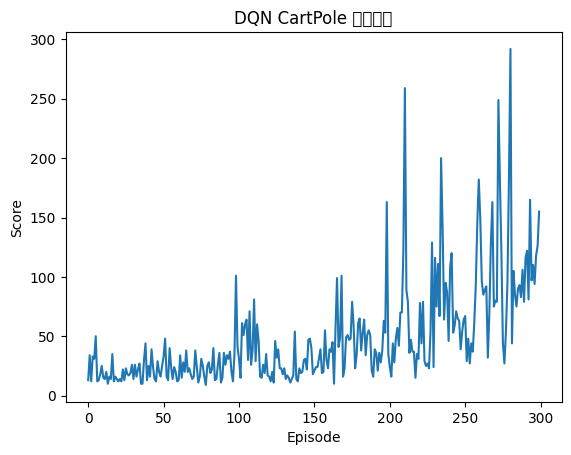

开始测试AI...


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [ ]:
plt.plot(scores)
plt.title('DQN CartPole 训练得分')
plt.ylabel('Score')
plt.xlabel('Episode')
plt.show()

# 测试AI
print("开始测试AI...")
for test_ep in range(10):
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])
    total_reward = 0
    while True:
        action = np.argmax(agent.model.predict(state, verbose=0)[0])
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = np.reshape(next_state, [1, state_size])
        total_reward += reward
        if done:
            break
    print(f"测试回合 {test_ep+1} 得分：{total_reward}")

env.close()